In [ ]:
# import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.preprocessing import OneHotEncoder

In [ ]:
# load csv
b_df = pd.read_csv('C:/CMI-DataScience-Project/atp_transformed/2000-2024 players.csv')

C:\Users\Golbe\AppData\Local\Temp\ipykernel_2172\1278216079.py:2: DtypeWarning: Columns (18,41,42) have mixed types. Specify dtype option on import or set low_memory=False.
  b_df = pd.read_csv('C:/CMI-DataScience-Project/atp_transformed/2000-2024 players_3.csv')


In [3]:
base_df = b_df.copy()

In [4]:
base_df['best_elo_reached'] = base_df.groupby('player_id')['elo'].max()

In [5]:
numeric_cols = base_df.select_dtypes(exclude=[np.number]).columns
print(numeric_cols)

Index(['tourney_id', 'tourney_name', 'surface', 'tourney_level',
       'tourney_date', 'score', 'tourney_round', 'tourney_type',
       'tourney_match_id', 'player_tourney_match_id', 'player_entry',
       'player_name', 'player_hand', 'player_country', 'round_1', 'round_2',
       'round_3', 'round_4', 'round_5', 'first_tourney_date'],
      dtype='object')


In [ ]:
base_df = base_df.drop(columns=['tourney_id', 'tourney_name','tourney_date', 'score', 'tourney_round', 'tourney_match_id', 'player_tourney_match_id', 'player_entry',
       'player_name', 'player_hand', 'round_1', 'round_2','round_3', 'round_4', 'round_5', 'first_tourney_date','tourney_type','player_country','match_num'])

In [7]:
encoder = OneHotEncoder(sparse_output=False, drop='first')  # drop first to avoid multicollinearity
surface_encoded = encoder.fit_transform(base_df[[
    'surface',
    #'player_country',
    'tourney_level'
    ]])
surface_df = pd.DataFrame(surface_encoded, 
                          columns=encoder.get_feature_names_out([
    'surface',
    #'player_country',
    'tourney_level'
                                                                 ]),
                          index=base_df.index)
df_encoded = pd.concat([base_df.drop([
    'surface',
    #'player_country',
    'tourney_level'
    ], axis=1), surface_df], axis=1)

In [8]:
#df_encoded.groupby('player_country')['best_elo_reached'].mean().sort_values()

In [10]:
target = "best_elo_reached"

corr_with_target = (
    df_encoded
    .corr()[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

In [11]:
corr_spearman = df_encoded.corr(method='spearman')['best_elo_reached'].sort_values(key=abs, ascending=False)

In [12]:
corr_spearman

best_elo_reached       1.000000
round_5_tb_numb        0.557157
player_id             -0.264320
round_4_tb_diff        0.244917
round_4_tb_outcome     0.244917
                         ...   
service_games          0.000761
points_on_serve        0.000625
player_hand_missing         NaN
tourney_level_25            NaN
tourney_level_O             NaN
Name: best_elo_reached, Length: 125, dtype: float64

In [ ]:
# All columns in your dataframe
all_features = df_encoded.columns.tolist()

# Keywords that indicate derivatives
exclude_terms = ('elo', 'rank','id')

# Keep only non-derivative features
independent_features = [
    col for col in all_features 
    if not any(term in col for term in exclude_terms)
]

# Make sure the target itself is excluded
target = 'best_elo_reached'
if target in independent_features:
    independent_features.remove(target)


len(independent_features)  # how many left


112

In [15]:
corr_with_target

round_5_tb_numb                    0.604891
round_4_tb_diff                    0.303173
round_4_tb_outcome                 0.303173
round_4_tb_numb                    0.237211
player_id                         -0.125877
                                     ...   
points_on_serve_rolling_mean_10    0.000375
round_3_outcome                    0.000082
player_hand_missing                     NaN
tourney_level_25                        NaN
tourney_level_O                         NaN
Name: best_elo_reached, Length: 124, dtype: float64

In [18]:
corr_with_target[abs(corr_with_target) > 0.1]

round_5_tb_numb       0.604891
round_4_tb_diff       0.303173
round_4_tb_outcome    0.303173
round_4_tb_numb       0.237211
player_id            -0.125877
Name: best_elo_reached, dtype: float64

In [19]:
corr_with_target

round_5_tb_numb                    0.604891
round_4_tb_diff                    0.303173
round_4_tb_outcome                 0.303173
round_4_tb_numb                    0.237211
player_id                         -0.125877
                                     ...   
points_on_serve_rolling_mean_10    0.000375
round_3_outcome                    0.000082
player_hand_missing                     NaN
tourney_level_25                        NaN
tourney_level_O                         NaN
Name: best_elo_reached, Length: 124, dtype: float64

In [26]:
cols = corr_with_target[abs(corr_with_target) > 0.2]

In [27]:
corr_with_target

round_5_tb_numb                    0.604891
round_4_tb_diff                    0.303173
round_4_tb_outcome                 0.303173
round_4_tb_numb                    0.237211
player_id                         -0.125877
                                     ...   
points_on_serve_rolling_mean_10    0.000375
round_3_outcome                    0.000082
player_hand_missing                     NaN
tourney_level_25                        NaN
tourney_level_O                         NaN
Name: best_elo_reached, Length: 124, dtype: float64

In [21]:
print(corr_with_target.index.to_list())

['round_5_tb_numb', 'round_4_tb_diff', 'round_4_tb_outcome', 'round_4_tb_numb', 'player_id', '2ndWon', 'double_faults', 'round_3_tb_diff', 'round_3_tb_outcome', '2ndWon_rolling_mean_10', 'tourney_level_S', 'player_rank_points', 'player_rank_rolling_mean_10', 'double_faults_rolling_mean_10', 'player_rank', 'player_seed', 'opponent_rank', 'round_1_tb_numb', 'tourney_level_C', 'opponent_elo_pre_match_rolling_mean_10', 'round_3_tb_numb', 'draw_size_rolling_med_10', 'minutes_rolling_med_10', 'break_points_faced', 'player_height', 'break_points_faced_rolling_mean_10', 'minutes', 'round_1_tb_outcome', 'round_1_tb_diff', 'round_5_tb_diff', 'elo_pre_match', 'mean_tb_numb', 'median_tb_numb', 'elo_pre_match_rolling_mean_10', 'elo_post_match', 'elo', 'ace_rolling_mean_10', 'mean_tb_diff', 'median_tb_diff', 'tb_dominance', 'player_age', 'opponent_elo_pre_match', 'first_serve_in_rolling_mean_10', 'median_diff_rolling_mean_10', 'match_num', 'round_4_diff', 'draw_size', 'round_4_numb', 'set_dominance'

In [28]:
strong_features = cols.index.tolist()

In [29]:
strong_unrelated_features = [x for x in strong_features if 'elo' not in x and 'rank' not in x]

In [30]:
strong_unrelated_features

['round_5_tb_numb', 'round_4_tb_diff', 'round_4_tb_outcome', 'round_4_tb_numb']

Plot all featuers against the target

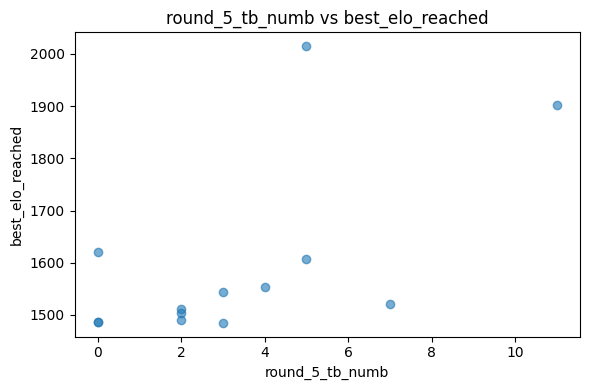

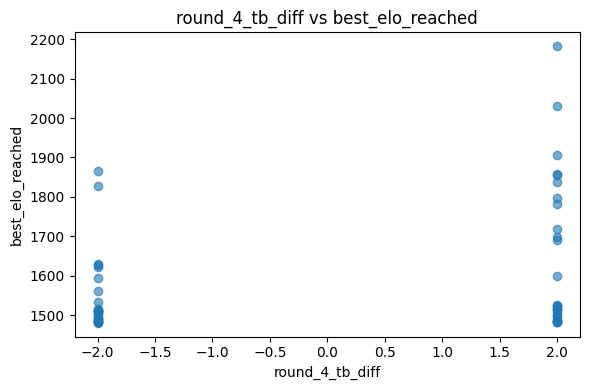

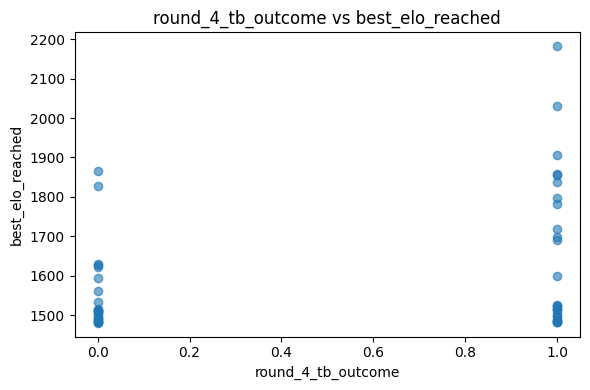

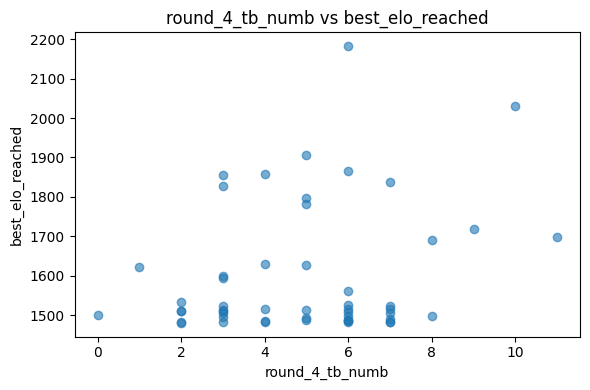

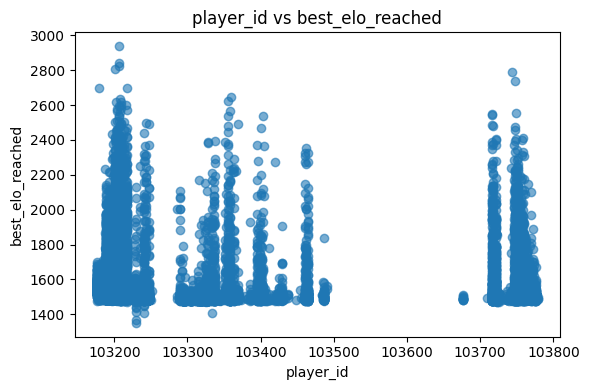

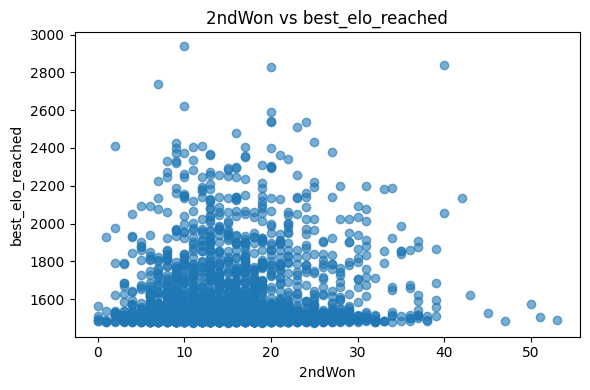

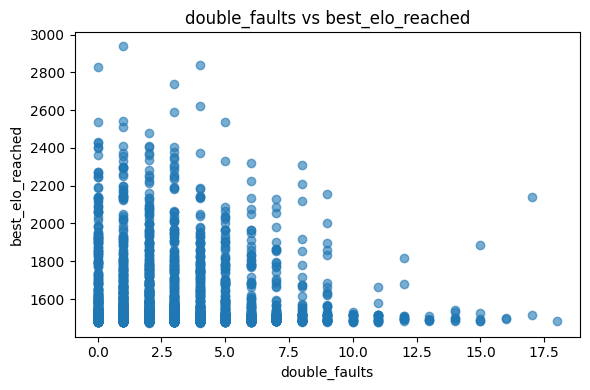

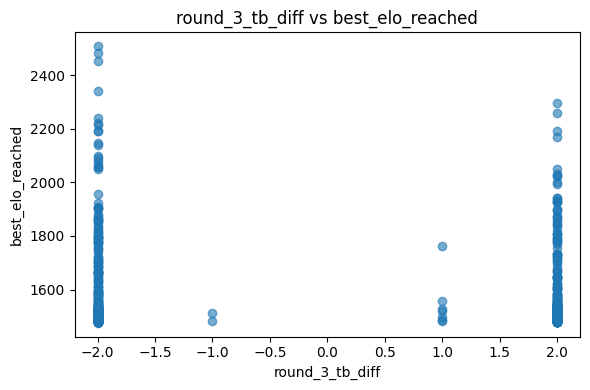

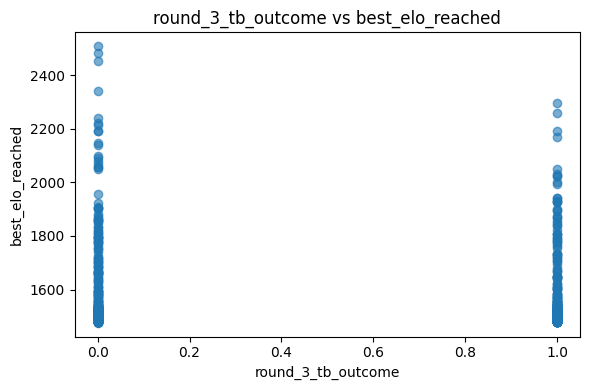

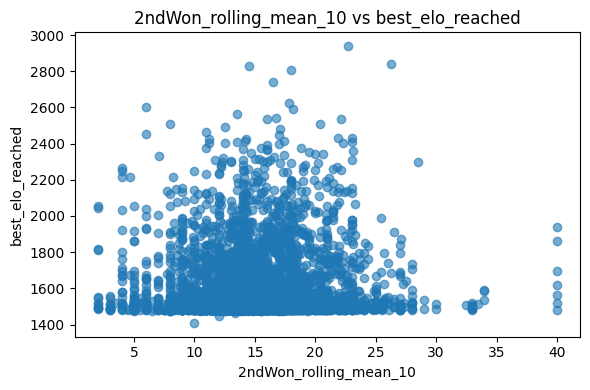

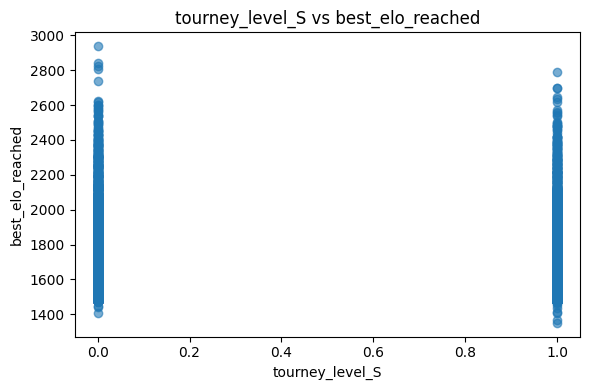

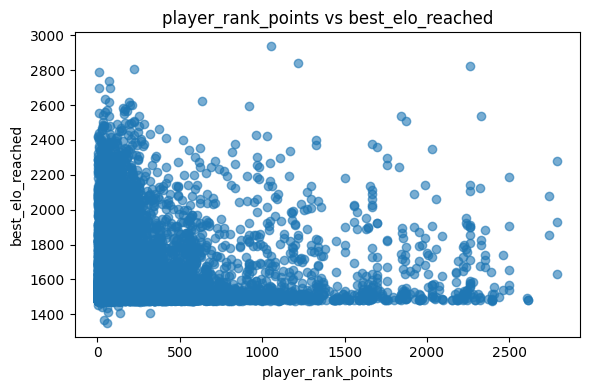

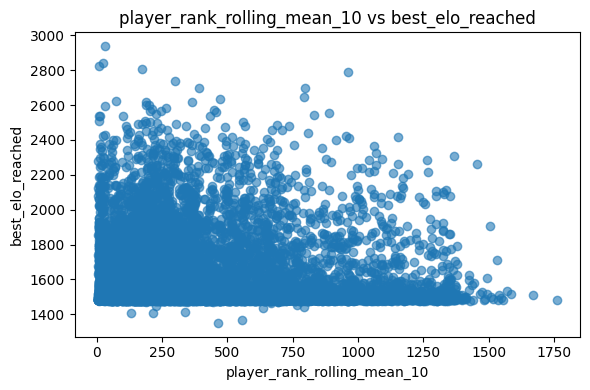

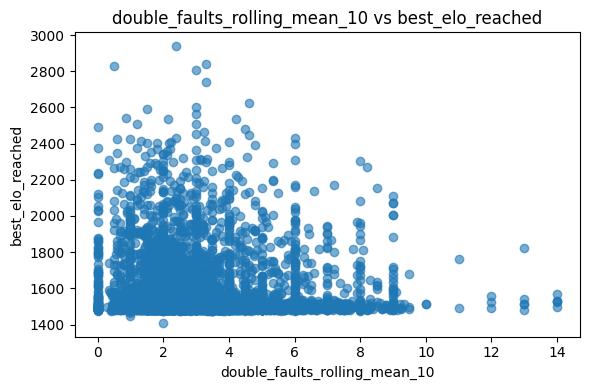

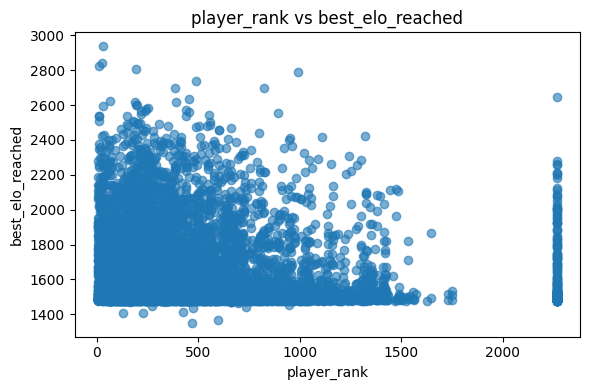

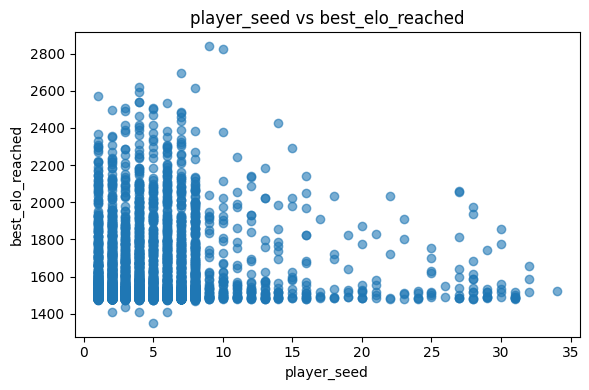

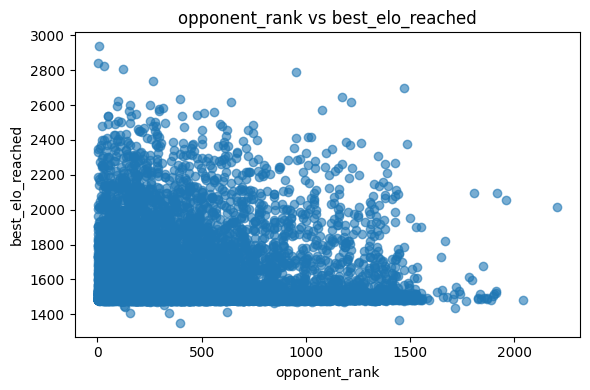

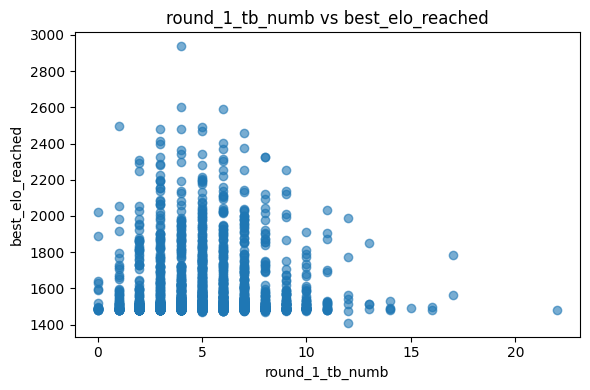

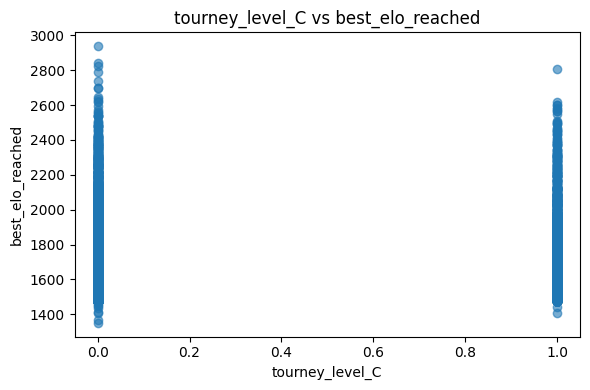

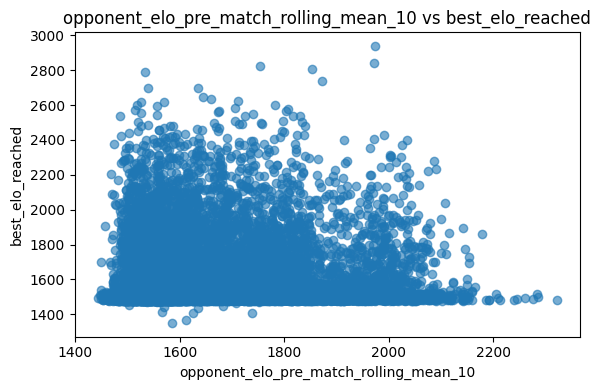

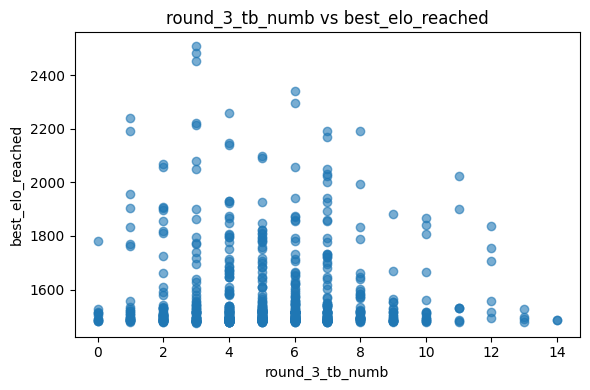

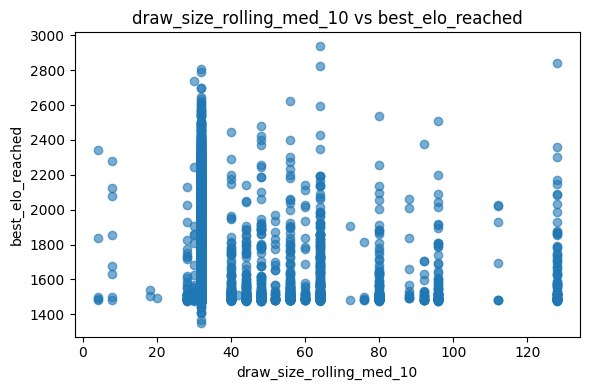

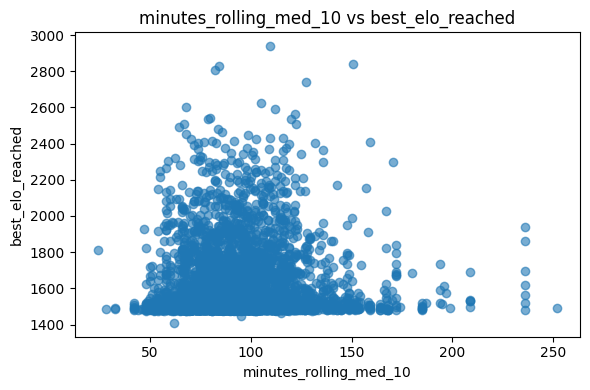

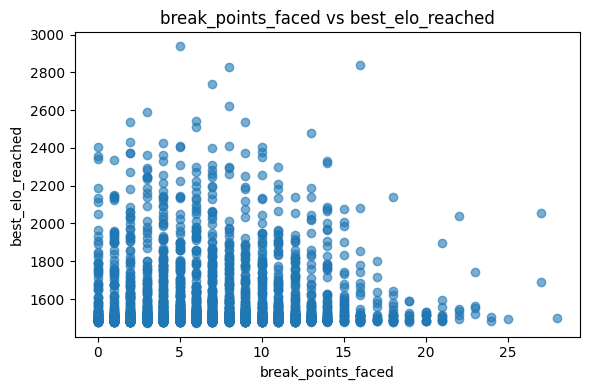

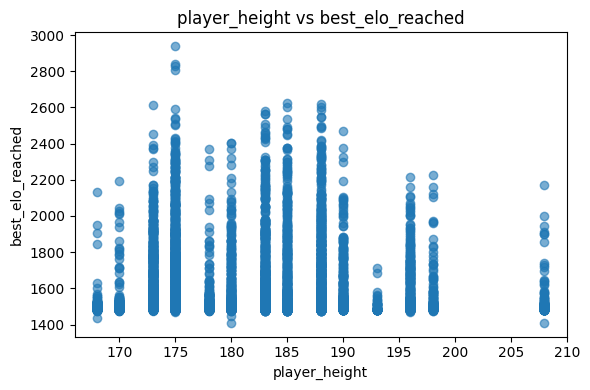

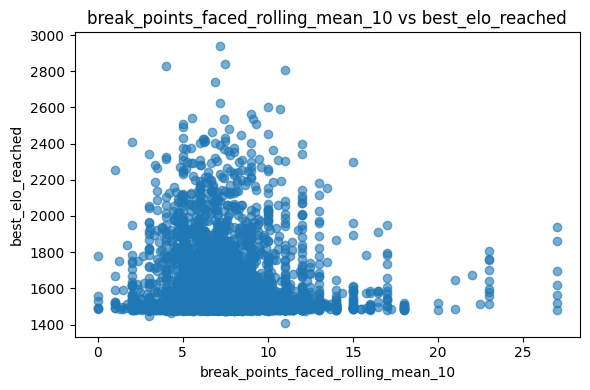

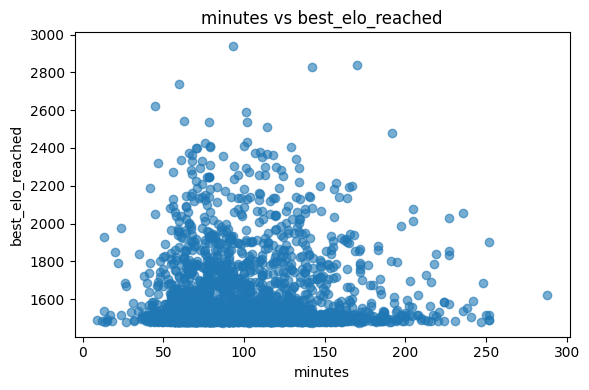

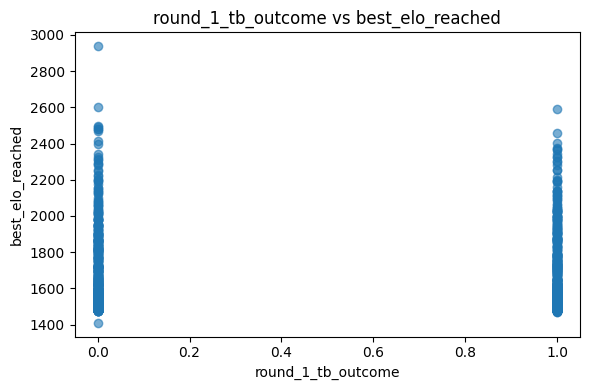

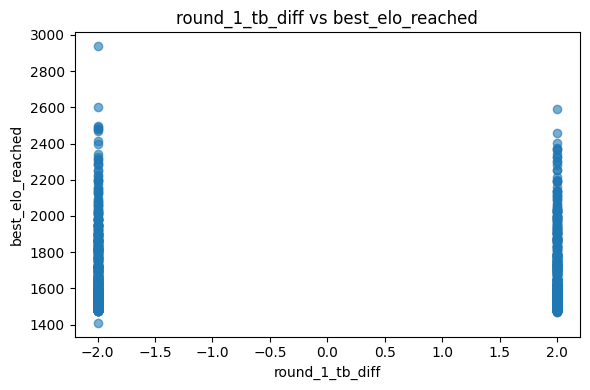

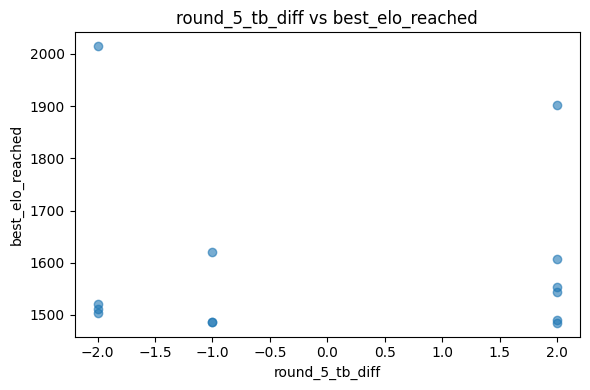

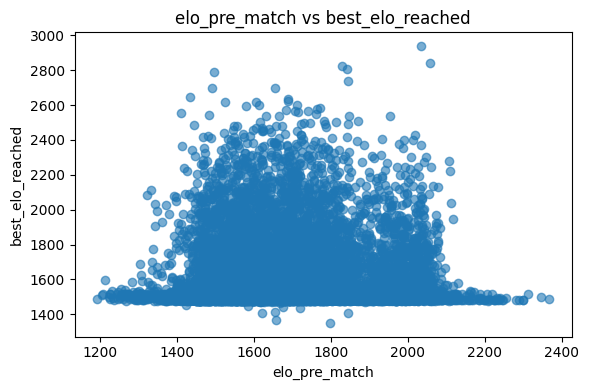

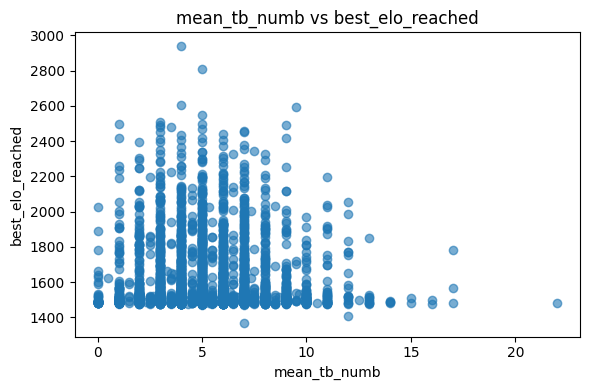

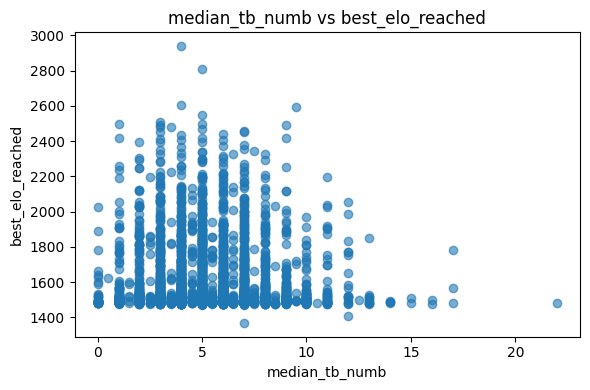

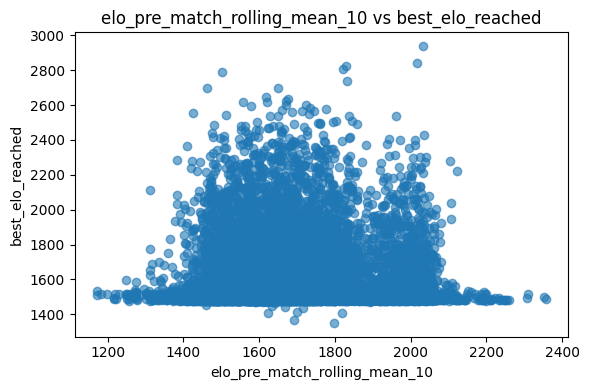

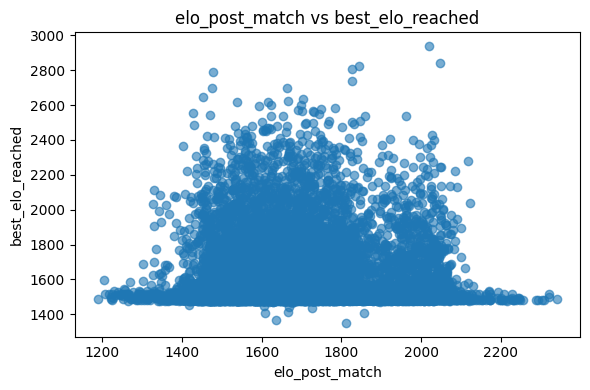

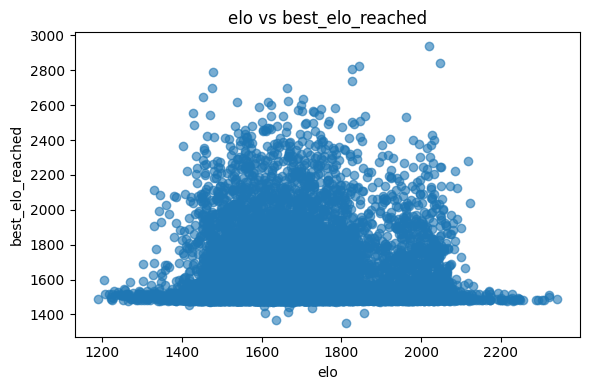

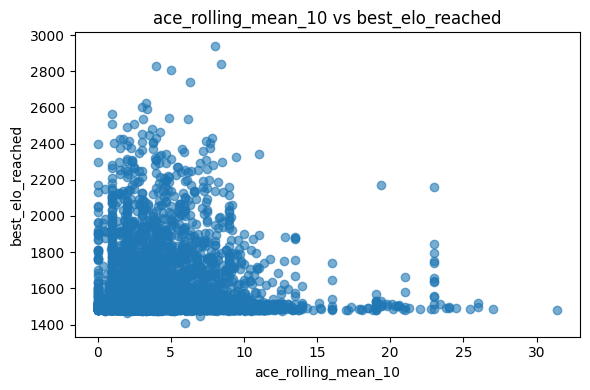

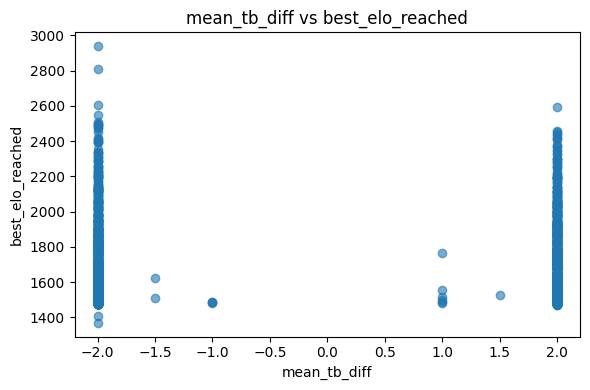

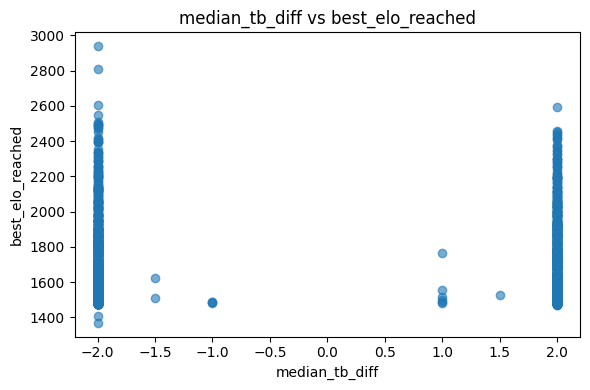

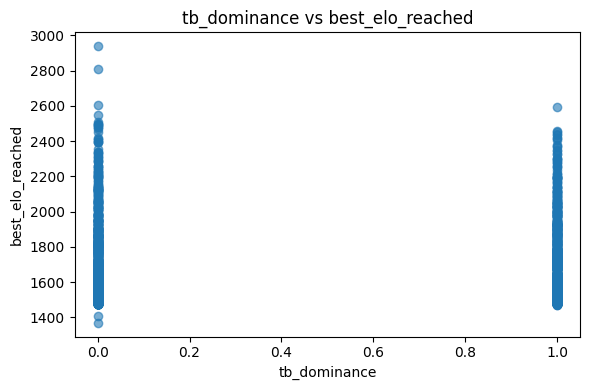

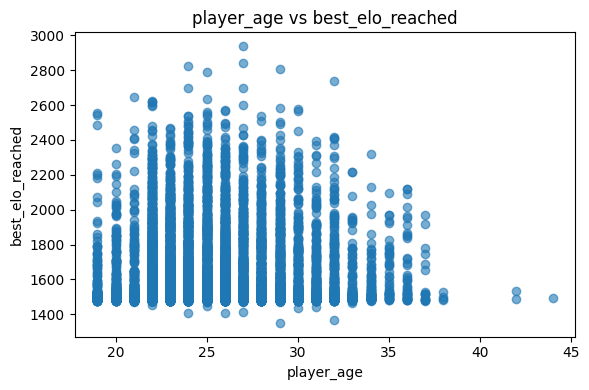

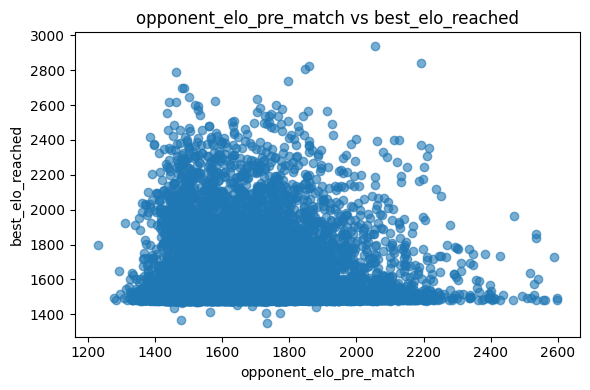

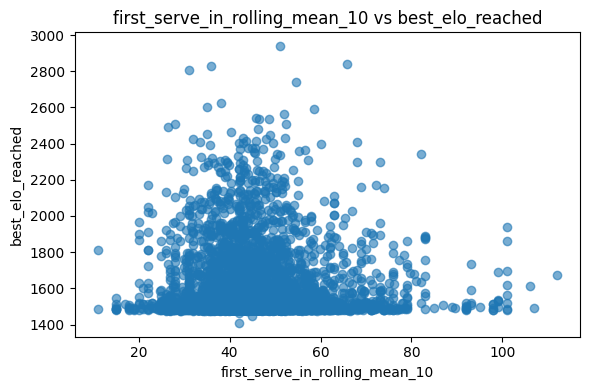

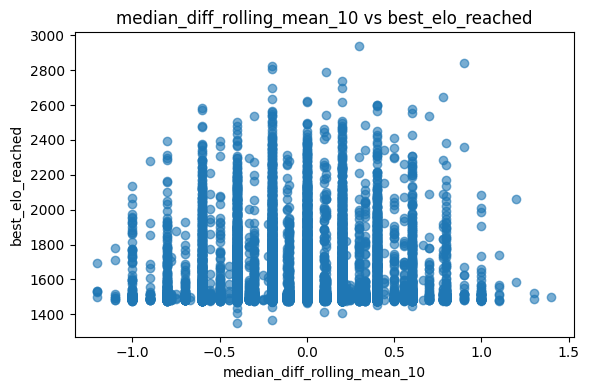

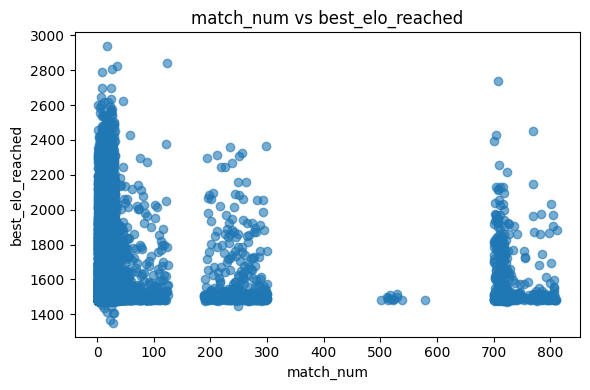

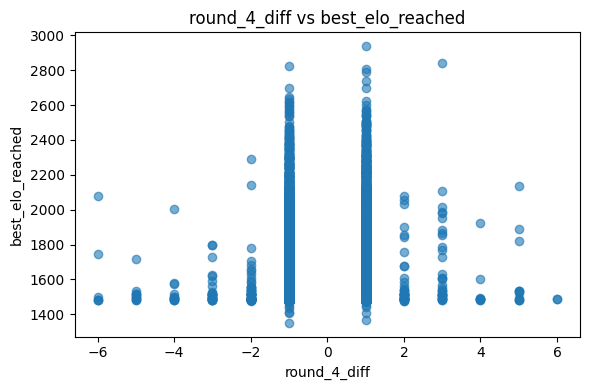

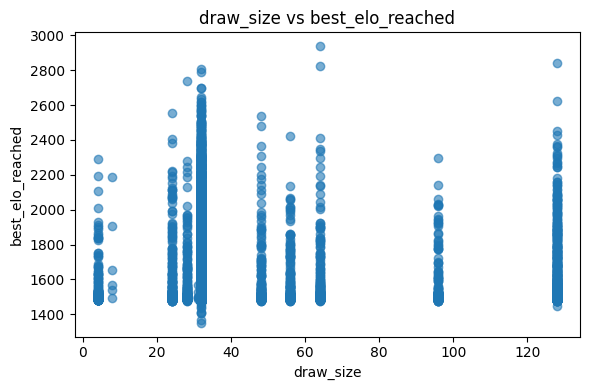

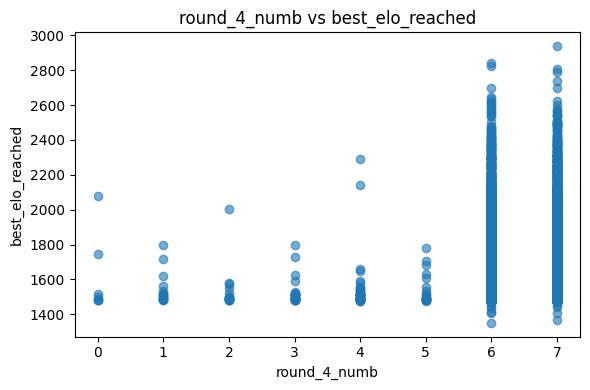

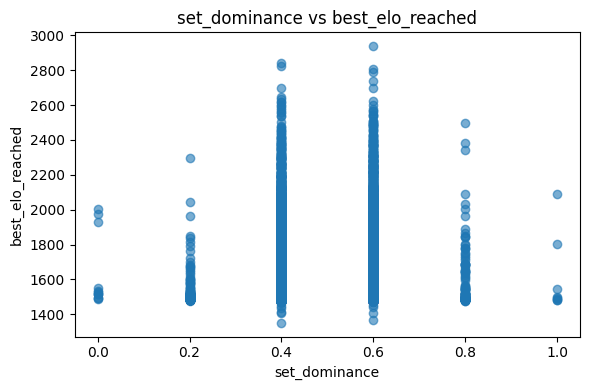

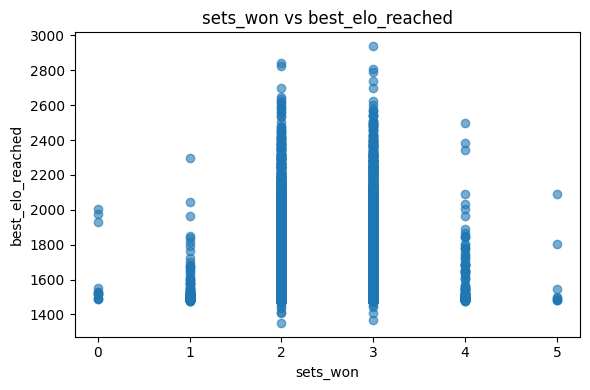

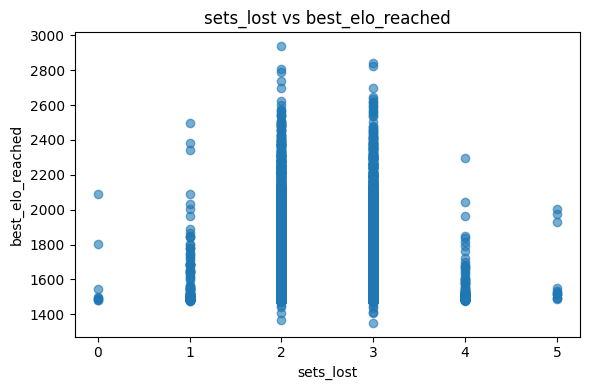

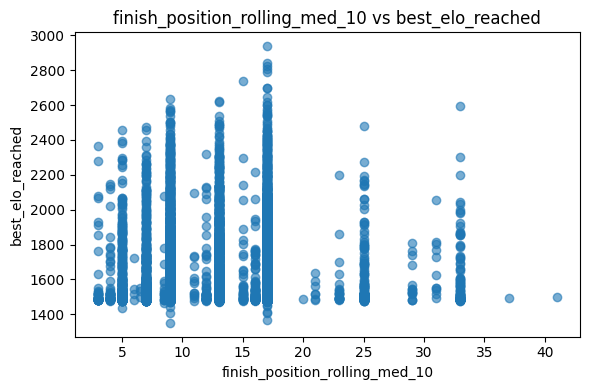

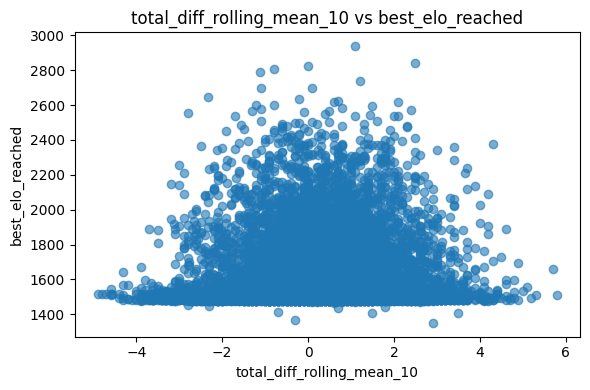

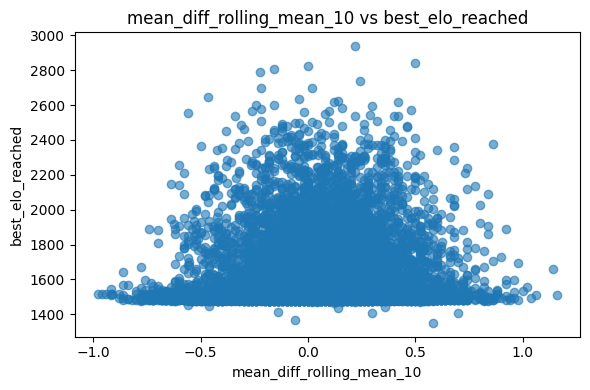

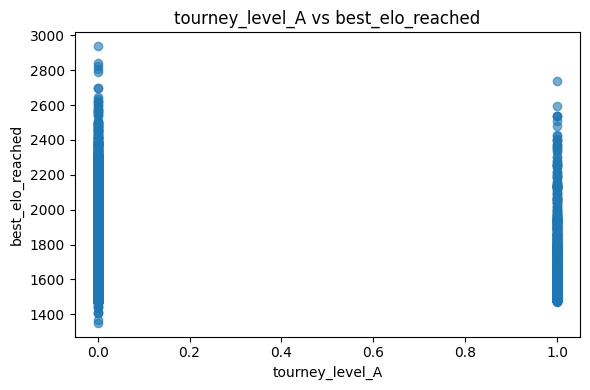

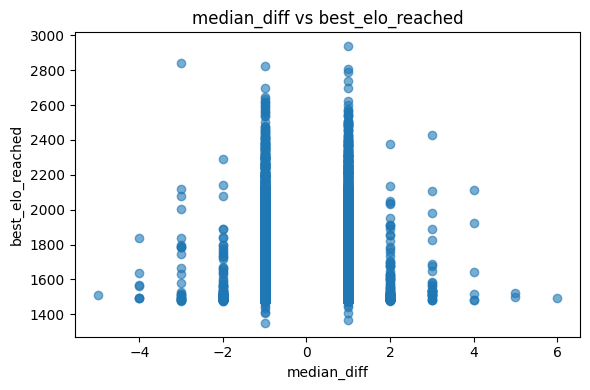

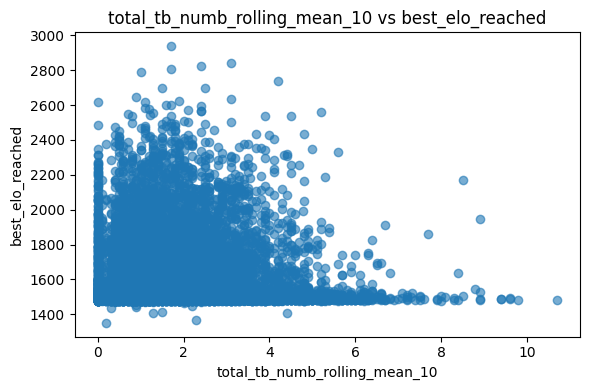

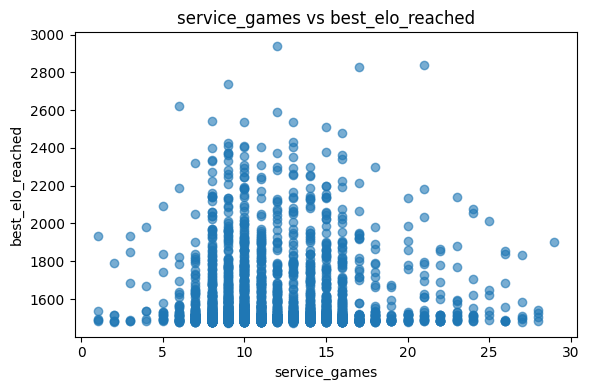

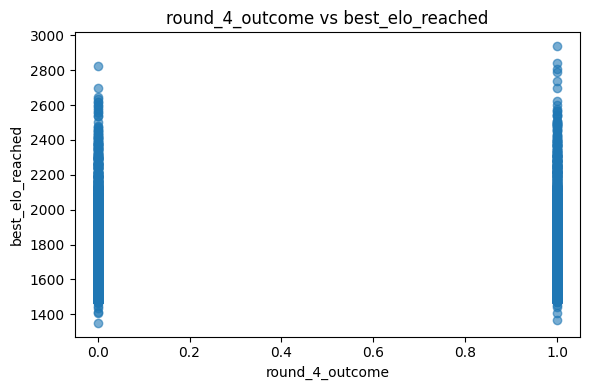

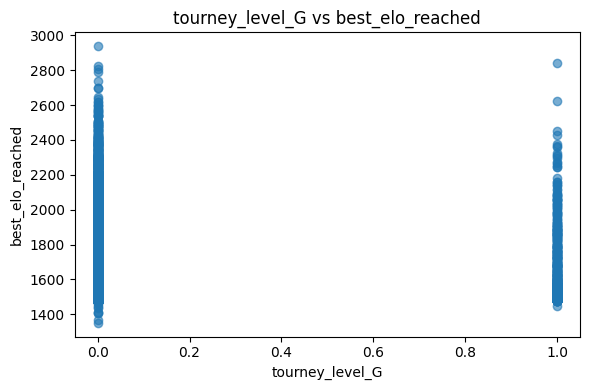

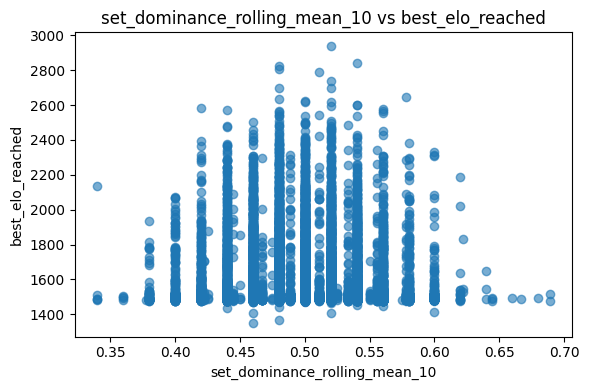

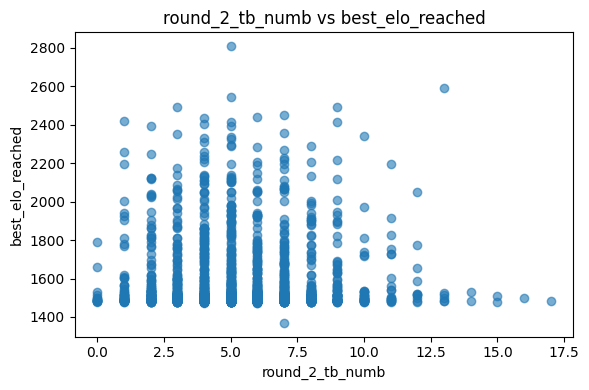

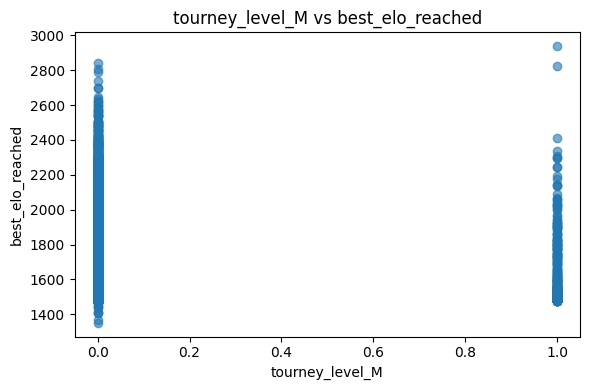

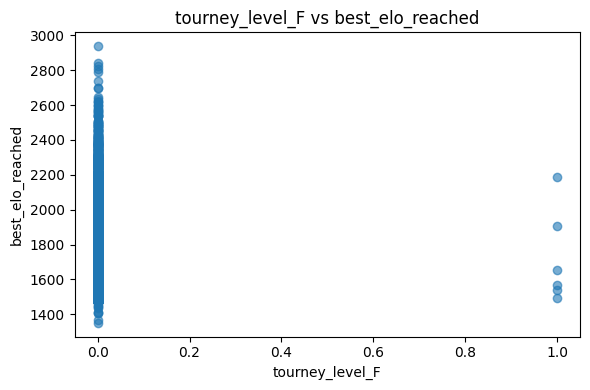

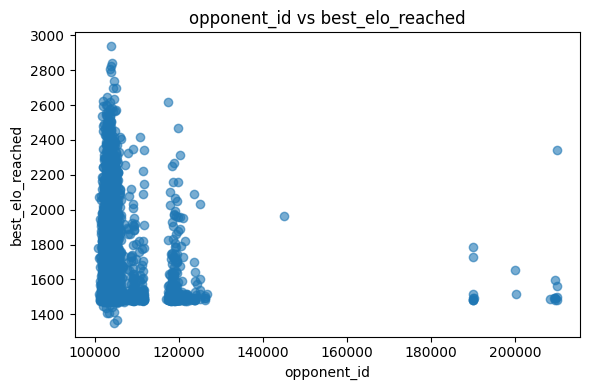

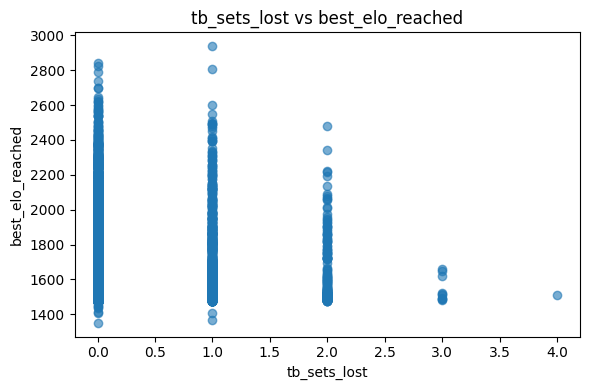

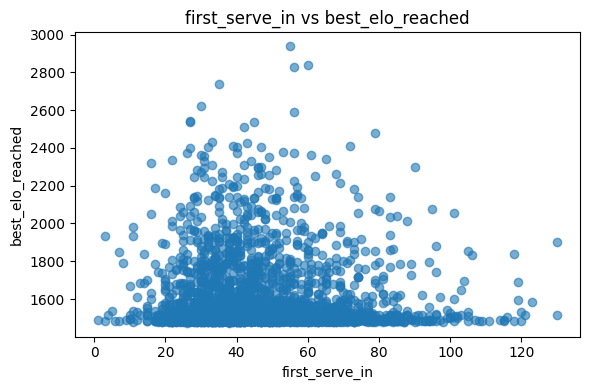

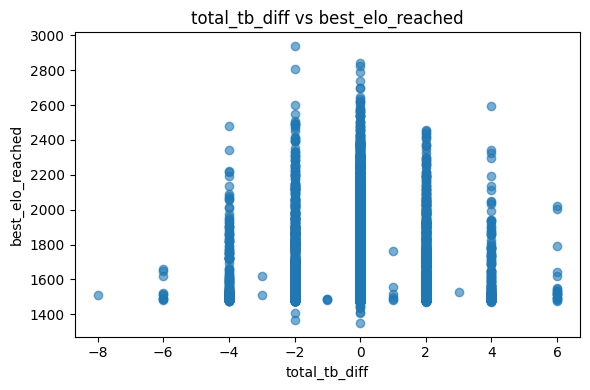

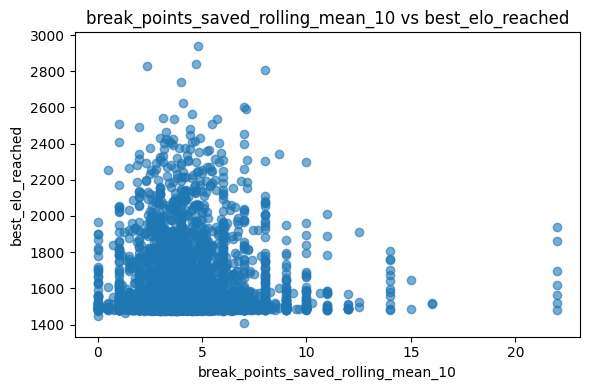

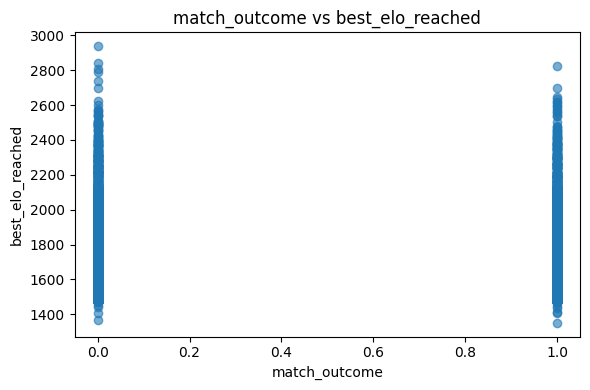

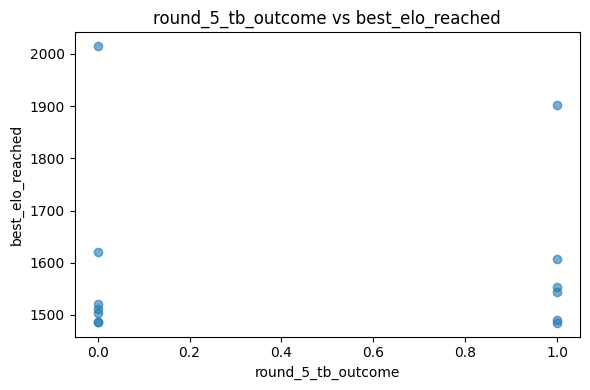

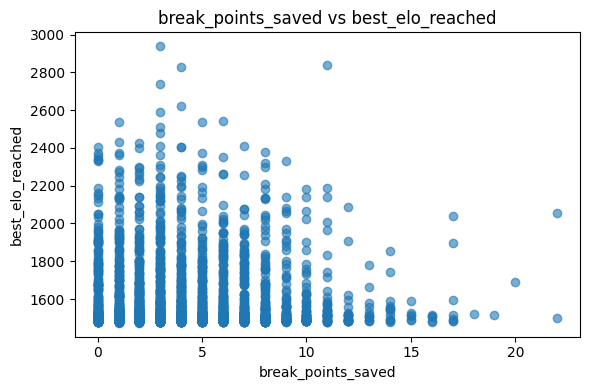

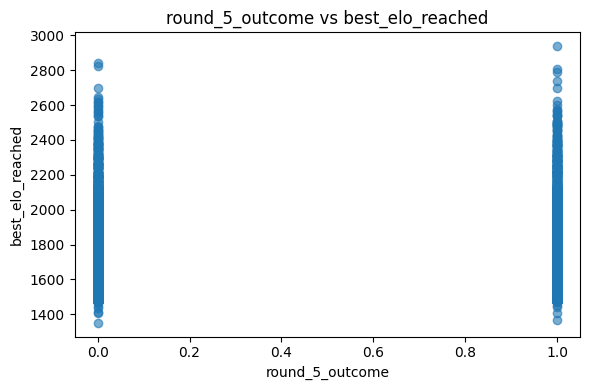

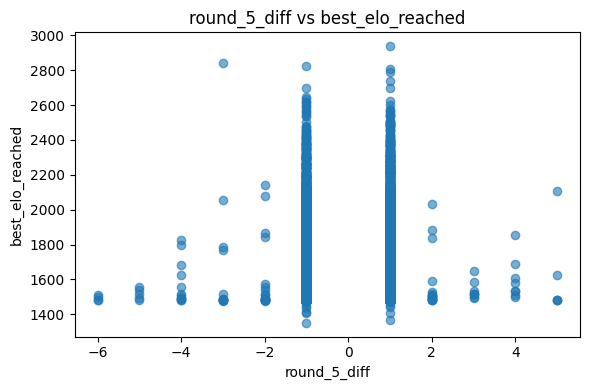

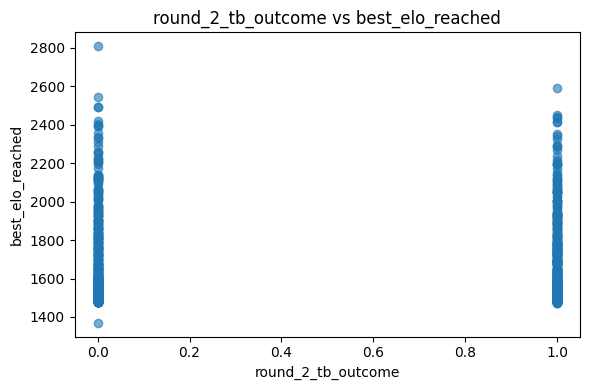

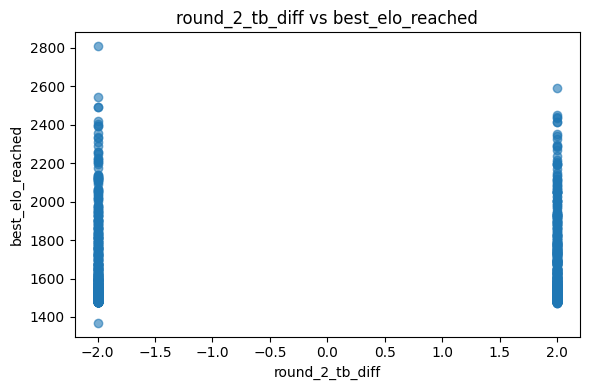

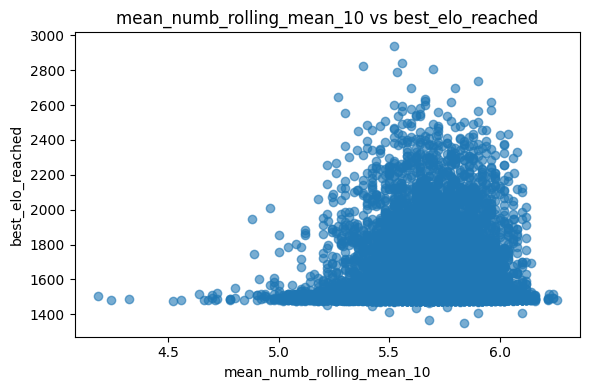

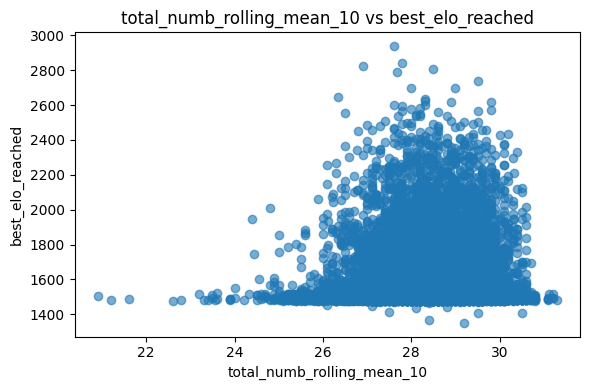

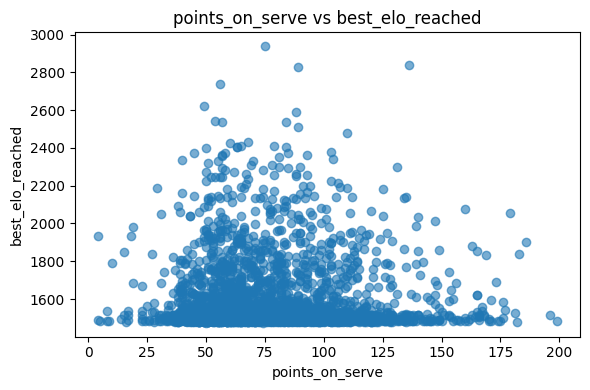

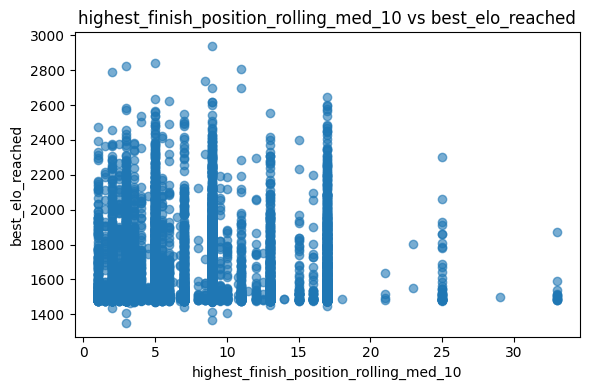

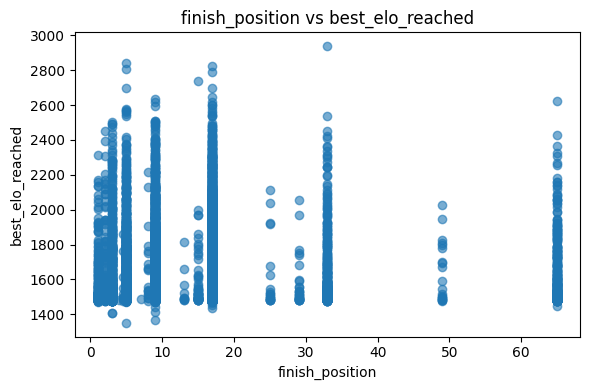

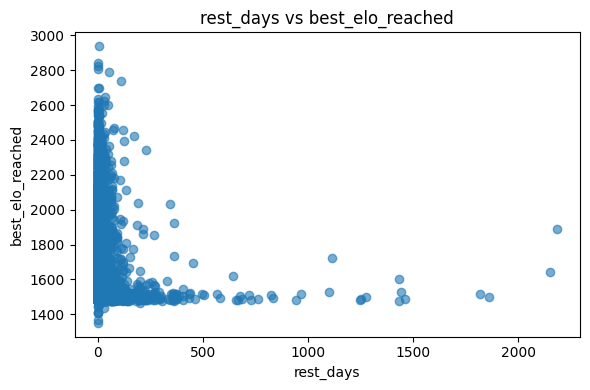

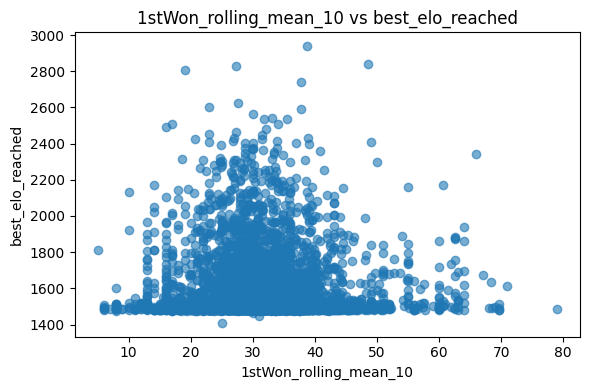

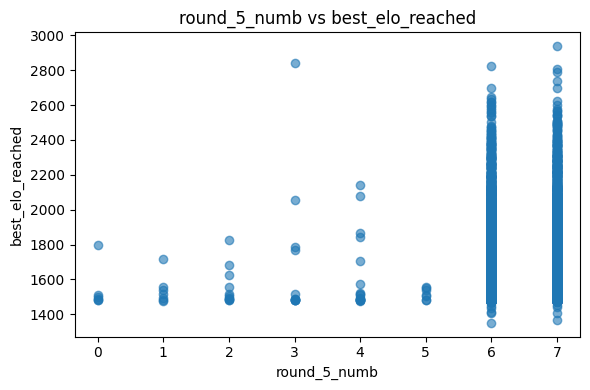

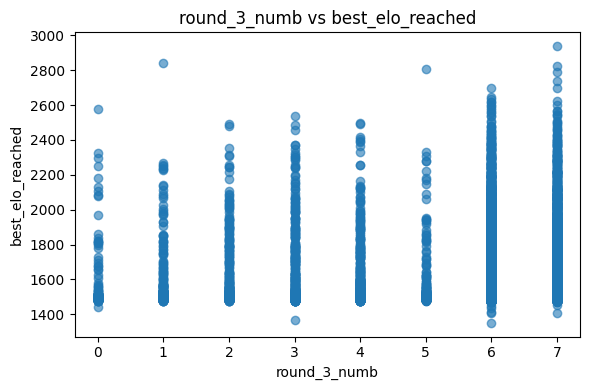

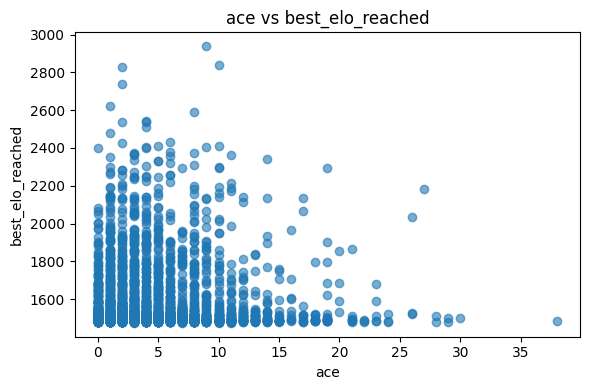

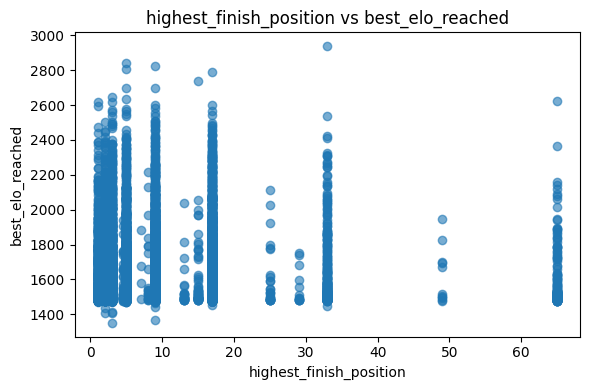

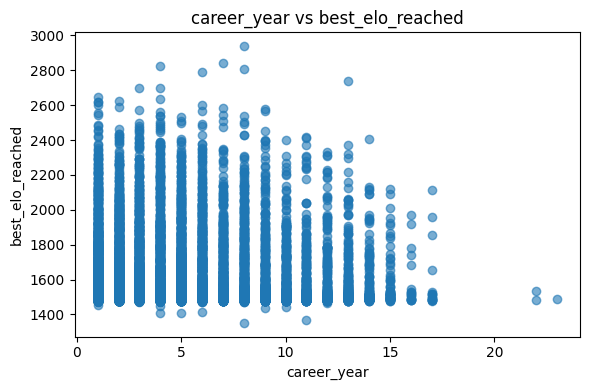

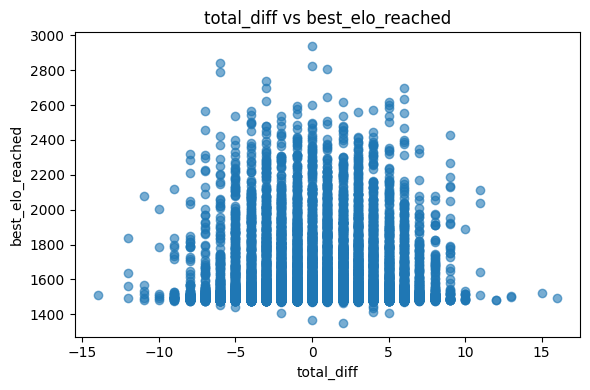

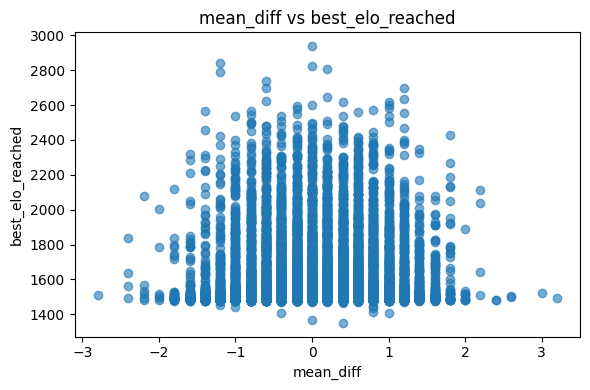

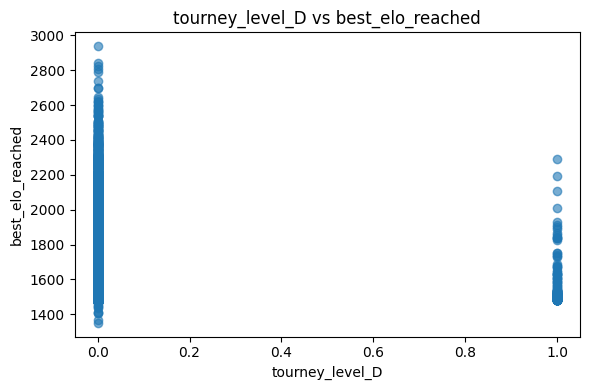

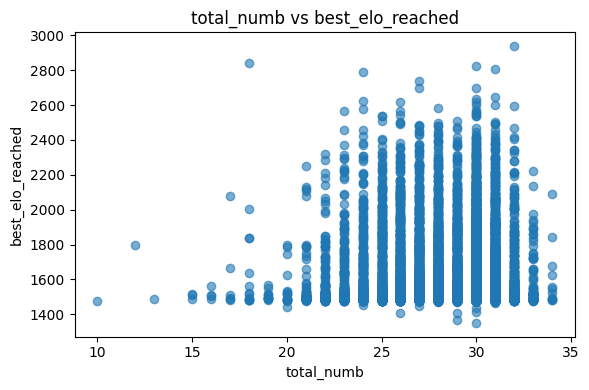

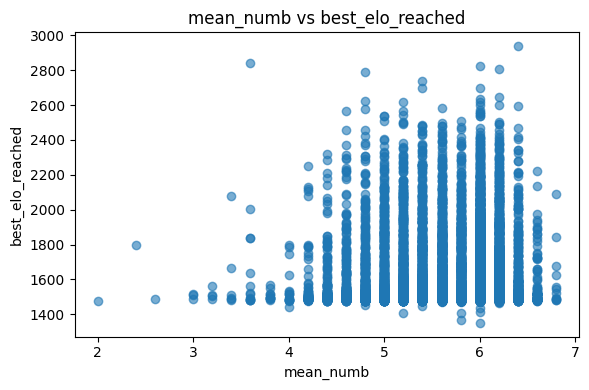

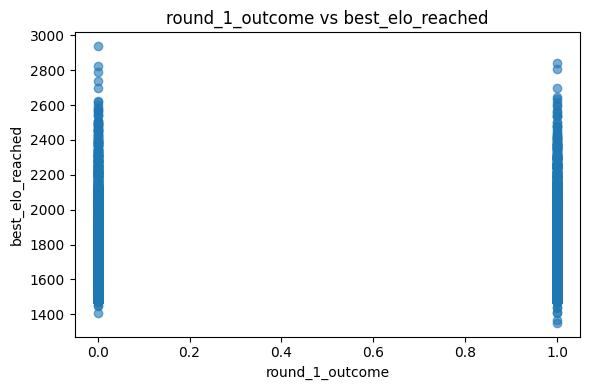

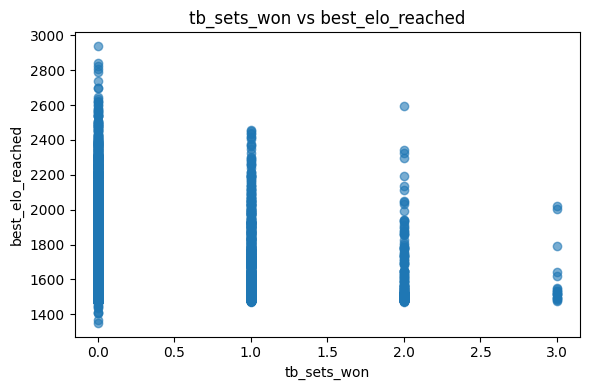

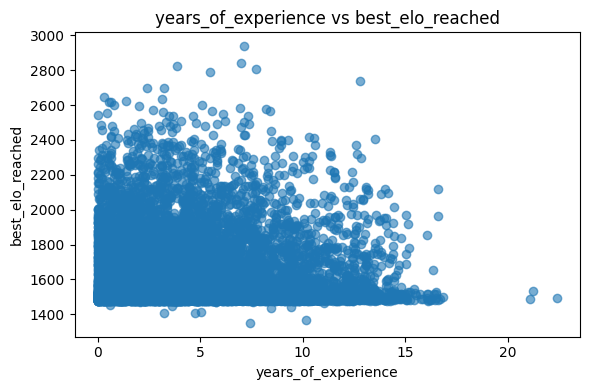

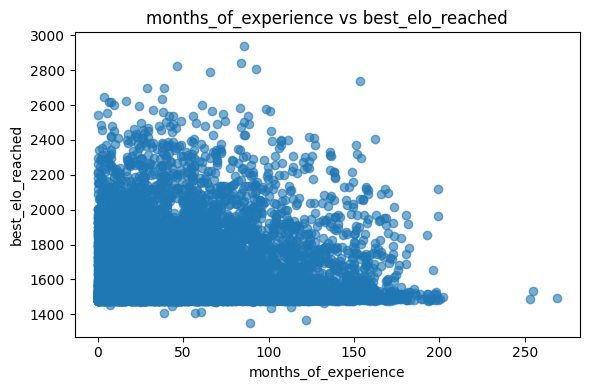

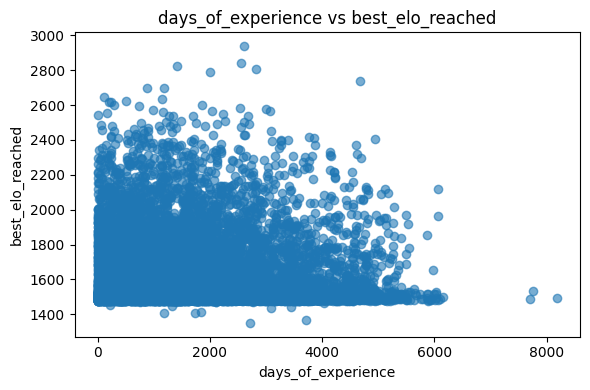

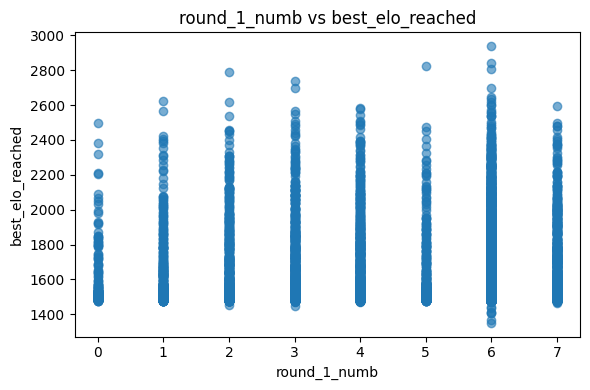

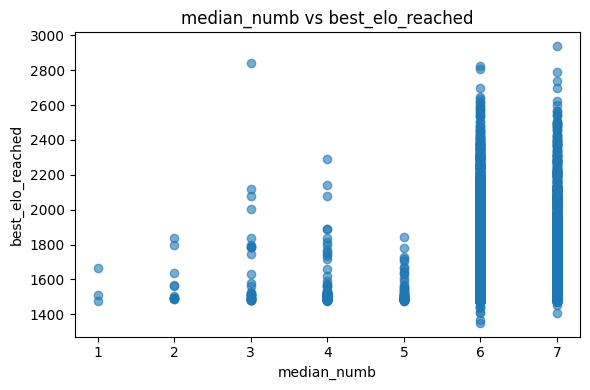

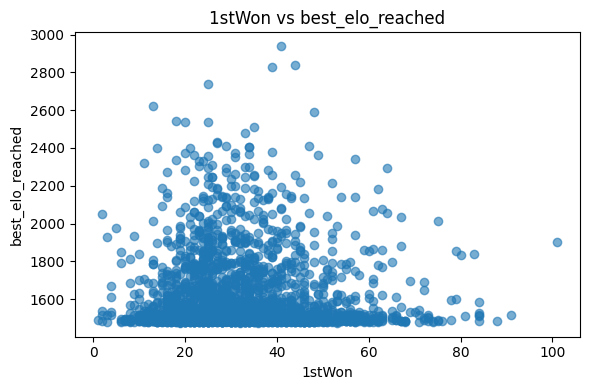

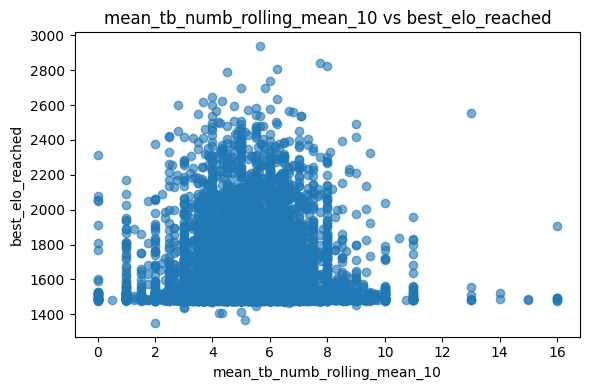

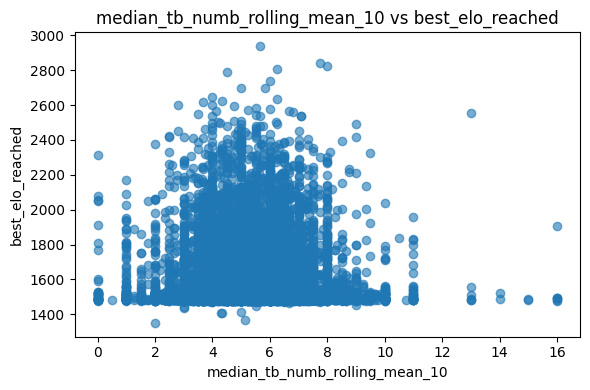

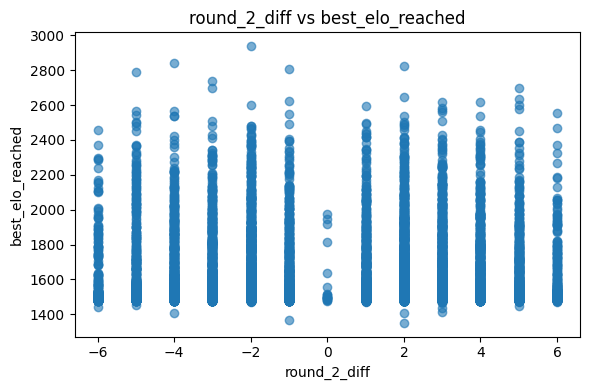

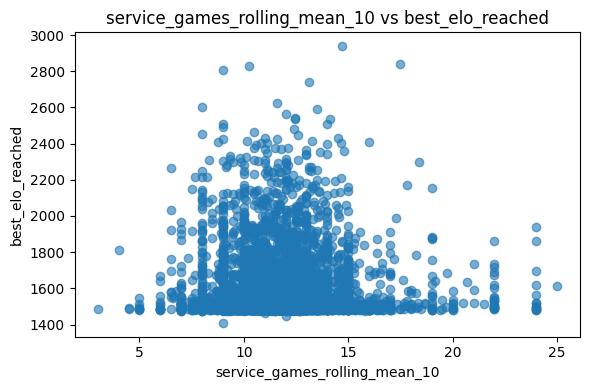

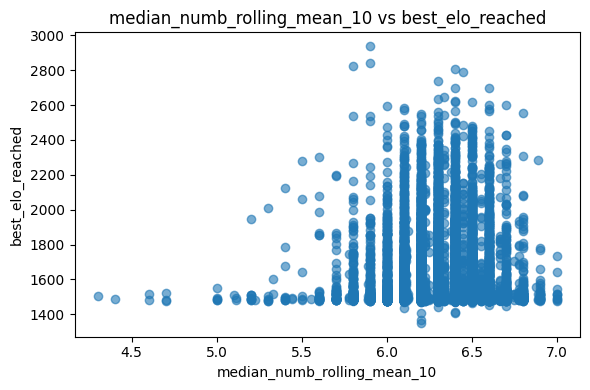

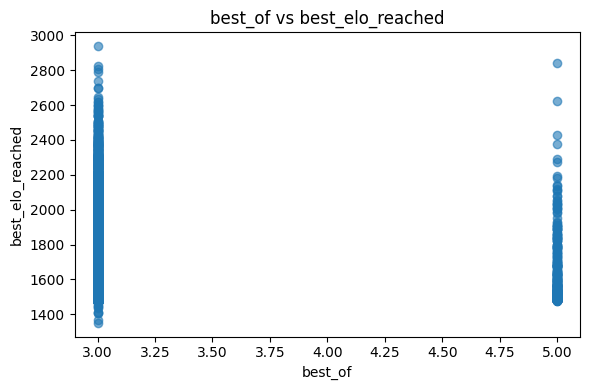

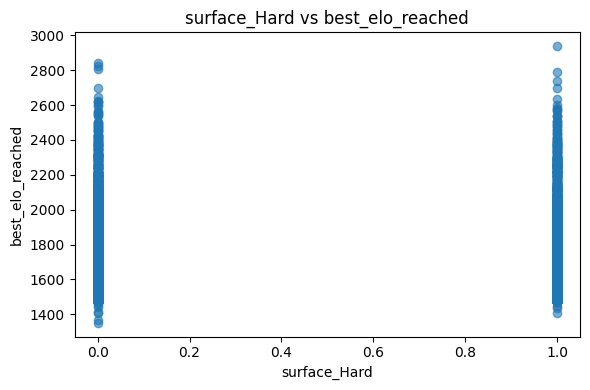

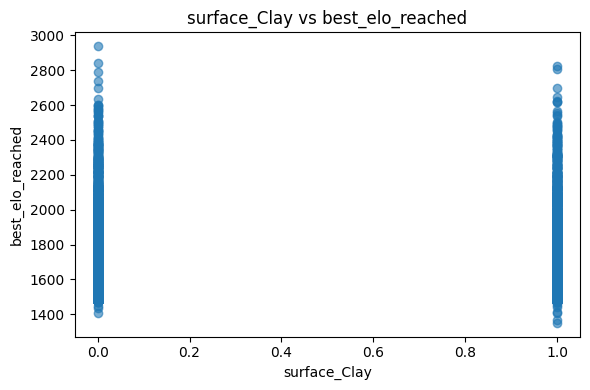

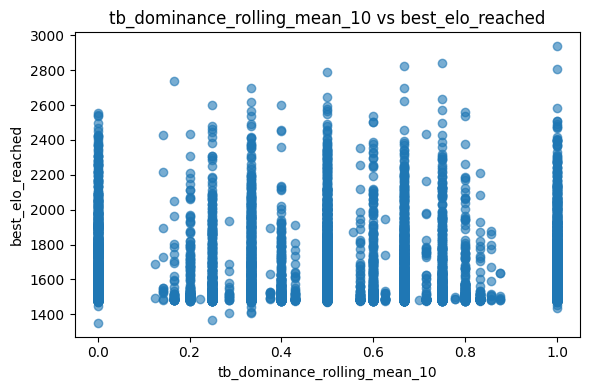

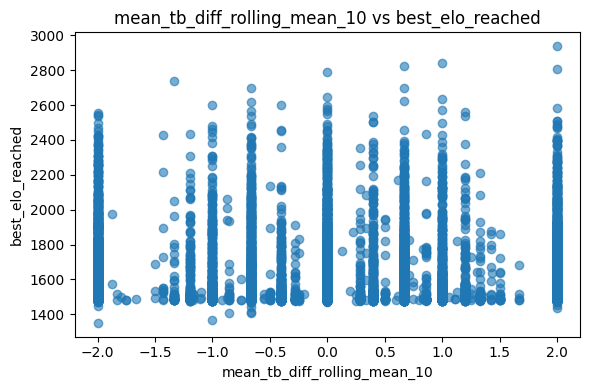

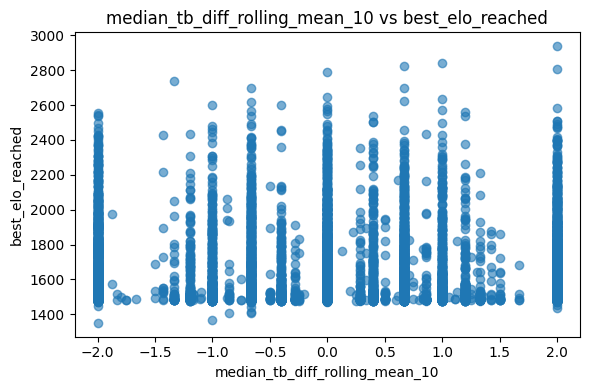

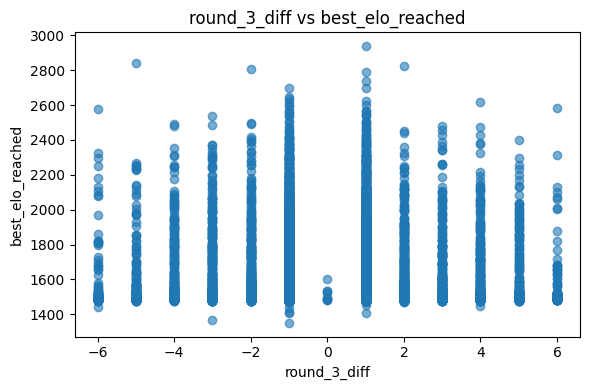

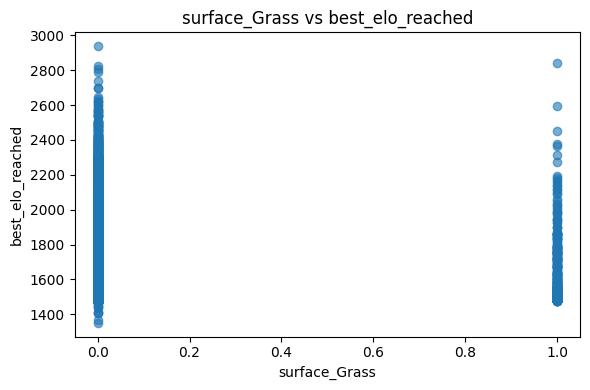

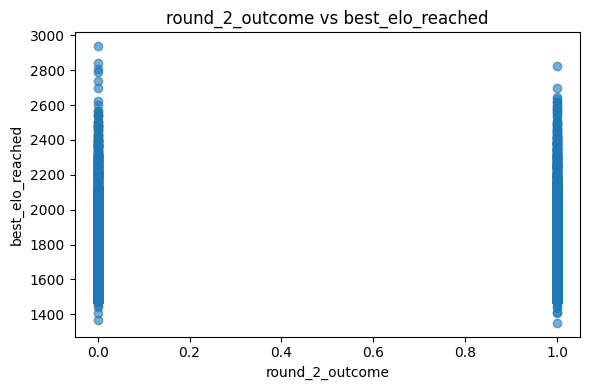

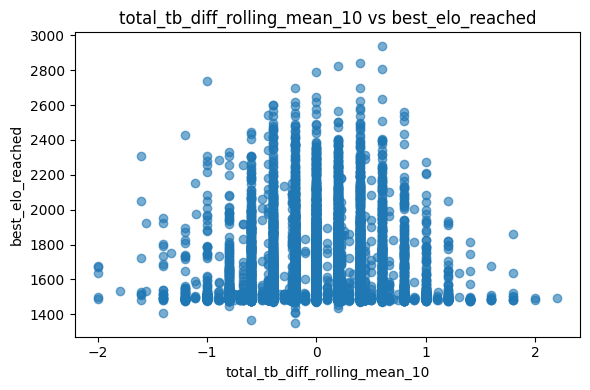

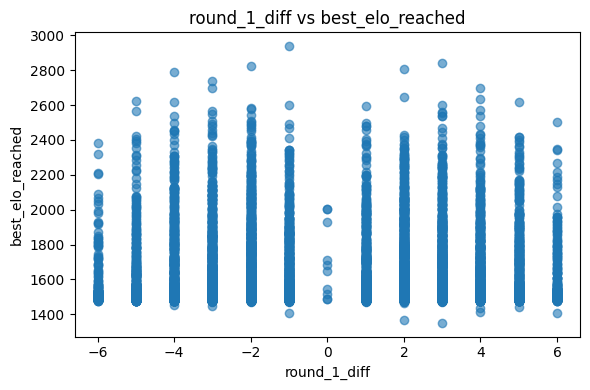

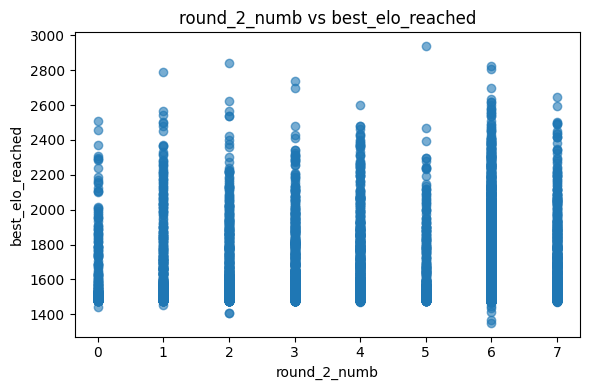

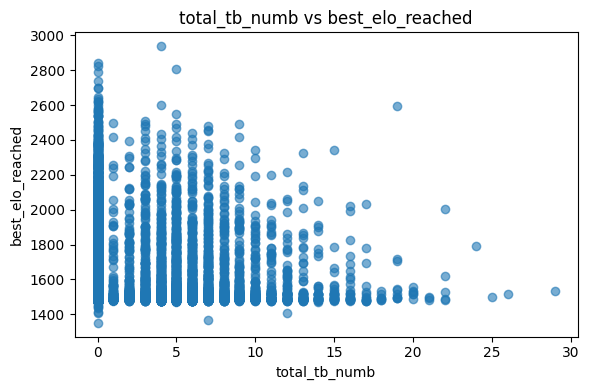

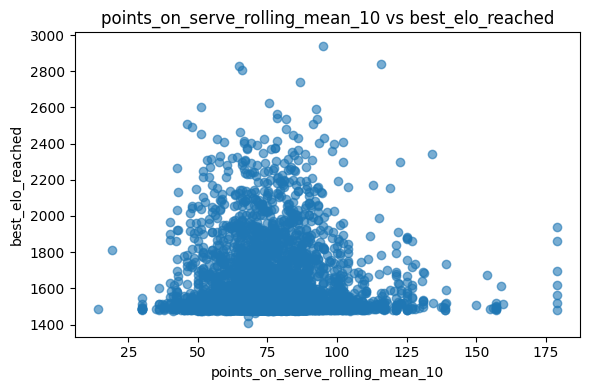

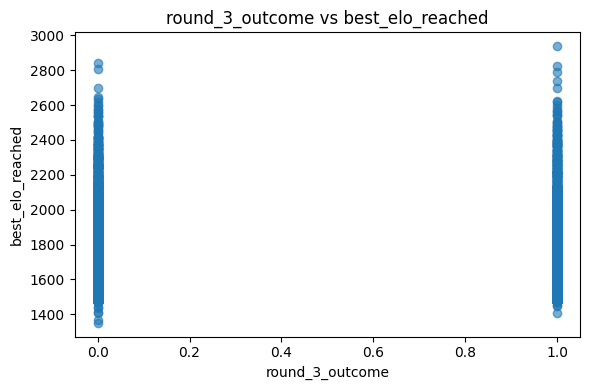

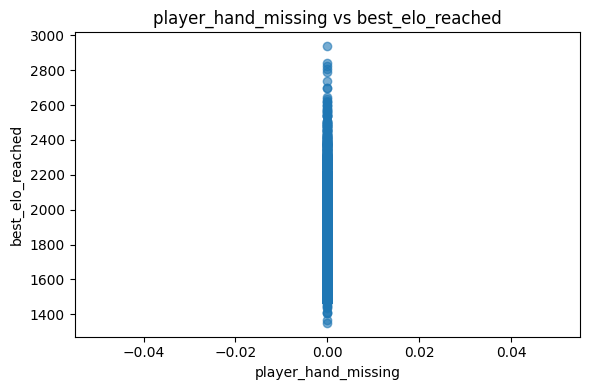

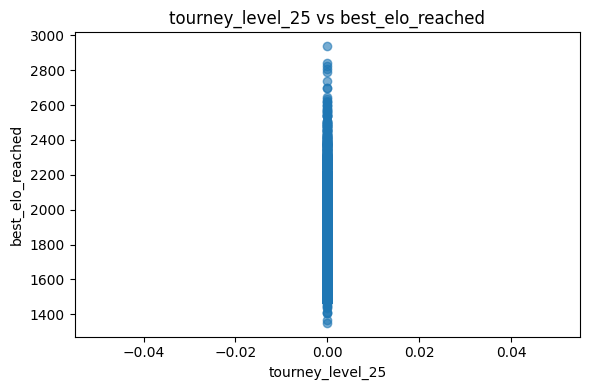

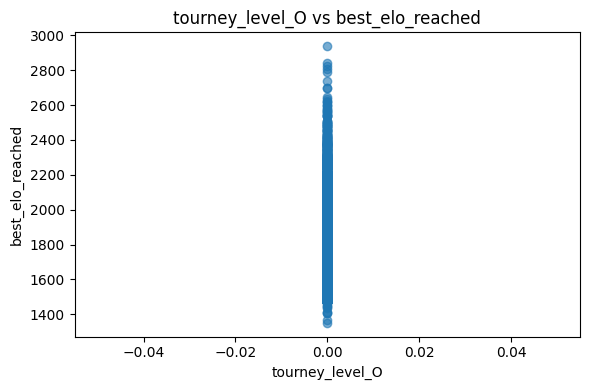

In [20]:
for feature in corr_with_target.index.to_list():
    plt.figure(figsize=(6, 4))
    plt.scatter(df_encoded[feature], df_encoded['best_elo_reached'], alpha=0.6)
    plt.title(f"{feature} vs best_elo_reached")
    plt.xlabel(feature)
    plt.ylabel("best_elo_reached")
    plt.tight_layout()
    plt.show()

In [34]:
# check best career
df_best_carr = b_df[['player_id','player_rank','elo','days_of_experience']]

df_best_carr = (
    b_df
    .groupby('player_id', as_index=False)
    .agg(
        player_rank=('player_rank', 'first'),
        elo=('elo', 'max'),
        days_of_experiece=('days_of_experience', 'first')
    )
)

In [35]:
df_best_carr

,player_id,player_rank,elo,days_of_experiece
0,100001,2268.0,1531.231343,0
1,100003,2268.0,1515.329690,0
2,100004,2268.0,1513.933382,0
3,100005,2268.0,1544.980799,0
4,100007,2268.0,NaN,0
...,...,...,...,...
19393,213496,2268.0,1499.943742,0
19394,213523,2268.0,NaN,0
19395,213608,2268.0,NaN,0
19396,213626,2268.0,NaN,0
